In [3]:
import yfinance as yf
import pandas as pd

# === USER INPUT ===
ticker = 'AAPL'
start_date = '2016-01-01'
end_date = '2023-12-31'
interval = '1d'  # options: 1d, 1wk, 1mo

# === FETCH DATA ===
df = yf.download(ticker, start=start_date, end=end_date, interval=interval, auto_adjust=True)

# === USE 'Close' COLUMN SINCE PRICES ARE AUTO-ADJUSTED ===
df = df[['Close']].dropna()
df.columns = ['Adj_Close']
df.reset_index(inplace=True)
df.tail()


[*********************100%***********************]  1 of 1 completed


,Date,Adj_Close
2007,2023-12-22,192.192566
2008,2023-12-26,191.646561
2009,2023-12-27,191.745819
2010,2023-12-28,192.172699
2011,2023-12-29,191.130325


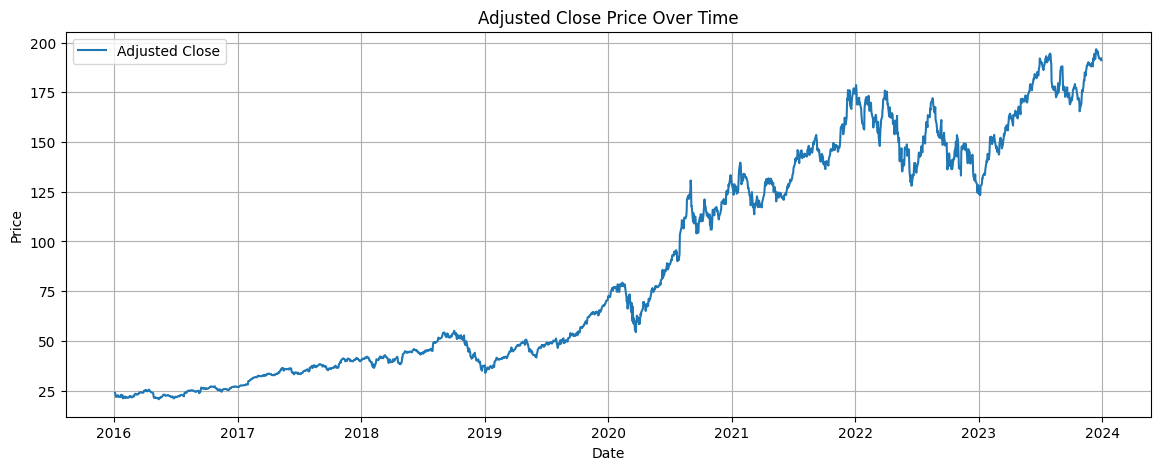

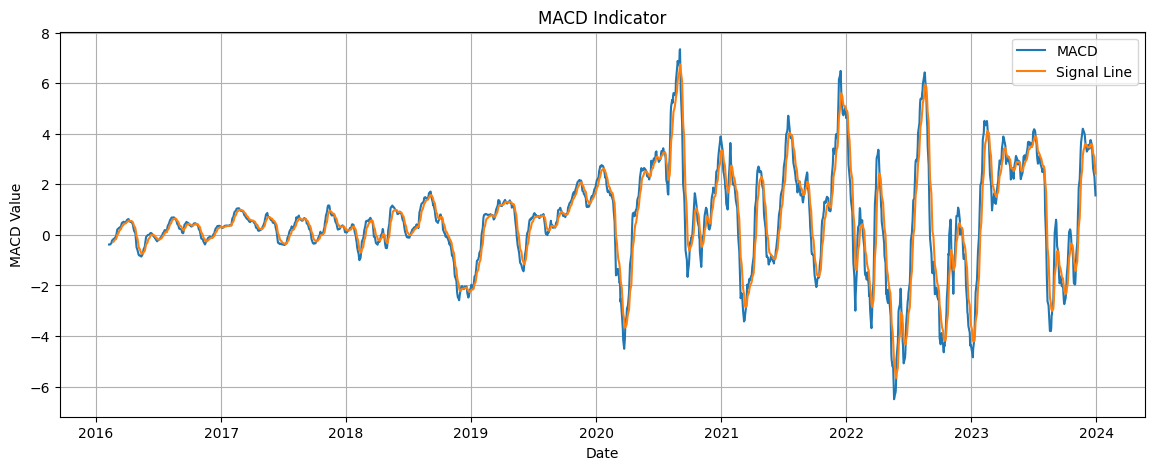

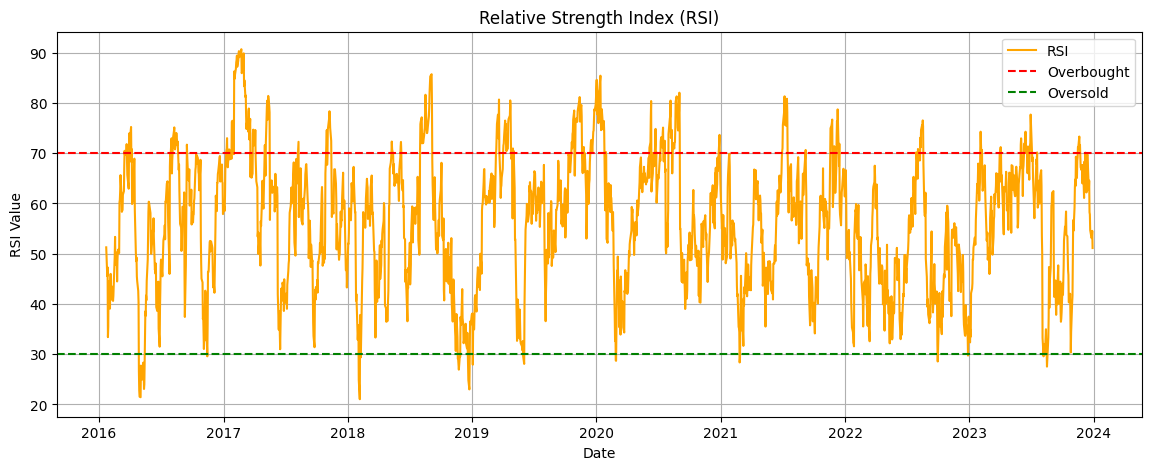

In [4]:
import matplotlib.pyplot as plt
from ta.trend import MACD
from ta.momentum import RSIIndicator

# === CALCULATE TECHNICAL INDICATORS ===
macd = MACD(close=df['Adj_Close'])
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()

rsi = RSIIndicator(close=df['Adj_Close'])
df['RSI'] = rsi.rsi()

# === PLOT 1: Adjusted Close Price ===
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Adj_Close'], label='Adjusted Close')
plt.title('Adjusted Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

# === PLOT 2: MACD ===
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_Signal'], label='Signal Line')
plt.title('MACD Indicator')
plt.xlabel('Date')
plt.ylabel('MACD Value')
plt.legend()
plt.grid()
plt.show()

# === PLOT 3: RSI ===
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['RSI'], label='RSI', color='orange')
plt.axhline(70, color='red', linestyle='--', label='Overbought')
plt.axhline(30, color='green', linestyle='--', label='Oversold')
plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.legend()
plt.grid()
plt.show()


In [5]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# === SELECT FEATURES ===
features = df[['Adj_Close', 'MACD', 'RSI']].dropna().reset_index(drop=True)

# === SCALE FEATURES ===
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)

# === SEQUENCE CREATION ===
sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)-15):  # Leave 15 for prediction
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i:i+15, 0])  # Predict next 15 values of Adj_Close only

X = np.array(X)
y = np.array(y)

# === TRAIN/TEST SPLIT ===
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# === LSTM MODEL ===
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(15)  # Output 15 future steps
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# === TRAIN MODEL ===
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)


C:\Users\rajam\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,407 (200.81 KB)

 Trainable params: 51,407 (200.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 0.0817 - val_loss: 0.0095
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0074 - val_loss: 0.0070
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0059 - val_loss: 0.0056
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0053 - val_loss: 0.0043
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0040 - val_loss: 0.0024
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0042 - val_loss: 0.0027
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0036 - val_loss: 0.0029
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0038 - val_loss: 0.0029
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0029 - val_loss: 0.0023
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 12/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
R² Score: 0.8037


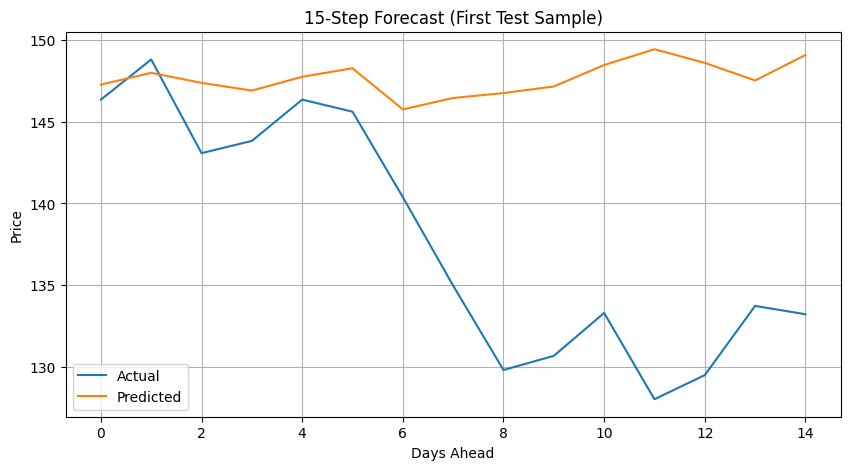

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === PREDICT ON TEST SET ===
y_pred = model.predict(X_test)

# === INVERSE TRANSFORM ===
# We only scaled 3 columns: Adj_Close, MACD, RSI
# So we need to rebuild the 3-column structure for inverse transform

def inverse_scale(preds, base_data):
    full = np.zeros((preds.shape[0], preds.shape[1], 3))
    full[:, :, 0] = preds  # Only Adj_Close predicted
    full[:, :, 1] = base_data[:, -1, 1][:, None]  # MACD (copied from last input)
    full[:, :, 2] = base_data[:, -1, 2][:, None]  # RSI (copied from last input)
    flat = full.reshape(-1, 3)
    inv = scaler.inverse_transform(flat)[:, 0]
    return inv.reshape(preds.shape)

y_test_inv = inverse_scale(y_test, X_test)
y_pred_inv = inverse_scale(y_pred, X_test)

# === R² SCORE ===
r2 = r2_score(y_test_inv.flatten(), y_pred_inv.flatten())
print(f"R² Score: {r2:.4f}")

# === PLOT COMPARISON FOR FIRST TEST SAMPLE ===
# === PLOT COMPARISON FOR FIRST TEST SAMPLE ===
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[0], label='Actual')
plt.plot(y_pred_inv[0], label='Predicted')
plt.title('15-Step Forecast (First Test Sample)')
plt.xlabel('Days Ahead')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()